# ⚡ Prefill vs Decode — Two Phases, Two Bottlenecks

**Post 9: Why Splitting LLM Inference in Two Makes Everything Faster**

LLM inference has two fundamentally different phases. Most systems run both on the same GPU. That's like using a sports car for both highway racing and parallel parking.

This notebook measures both phases separately to show exactly why they're different.

**Hardware:** Colab Pro A100 or T4

In [1]:
!pip install -q transformers accelerate matplotlib pandas tqdm

In [3]:
import torch, time, gc, numpy as np, matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto"
)
print(f"Model loaded: {sum(p.numel() for p in model.parameters())/1e9:.1f}B params")

GPU: Tesla T4
VRAM: 15.6 GB


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded: 3.1B params


## 1. Measure Prefill Phase

Prefill processes the **entire input prompt at once** in parallel. This phase is **compute-bound** — it maxes out GPU FLOPs.

We measure: how fast can the model process prompts of different lengths?

In [4]:
# Measure PREFILL: time to process the input (first forward pass)
# This is the phase that processes your prompt before generating

context_lengths = [128, 256, 512, 1024, 2048, 4096]
base_text = "Explain the complete history of computing in great detail. " * 500

prefill_results = []

print("=" * 60)
print("  PREFILL PHASE — Processing Input Prompts")
print("=" * 60)

for ctx_len in context_lengths:
    tokens = tokenizer(base_text, return_tensors="pt",
                       max_length=ctx_len, truncation=True)
    input_ids = tokens["input_ids"].to(model.device)
    actual_len = input_ids.shape[1]

    # Warmup
    with torch.no_grad():
        _ = model(input_ids)

    # Benchmark prefill (3 runs)
    times = []
    for _ in range(3):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            outputs = model(input_ids)
        torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)

    avg_time = np.mean(times)
    tokens_per_sec = actual_len / avg_time

    prefill_results.append({
        "ctx": actual_len,
        "time_ms": avg_time * 1000,
        "tps": tokens_per_sec,
    })
    print(f"  {actual_len:>5} tokens | {avg_time*1000:.1f} ms | {tokens_per_sec:.0f} tok/s prefill")

print("\nKey insight: prefill TPS is MUCH higher than decode TPS")
print("because all tokens are processed in parallel (matrix multiply)")

  PREFILL PHASE — Processing Input Prompts
    128 tokens | 79.3 ms | 1614 tok/s prefill
    256 tokens | 105.5 ms | 2427 tok/s prefill
    512 tokens | 211.1 ms | 2425 tok/s prefill
   1024 tokens | 481.2 ms | 2128 tok/s prefill
   2048 tokens | 1272.5 ms | 1609 tok/s prefill
   4096 tokens | 4098.6 ms | 999 tok/s prefill

Key insight: prefill TPS is MUCH higher than decode TPS
because all tokens are processed in parallel (matrix multiply)


## 2. Measure Decode Phase

Decode generates tokens **one at a time**, each depending on the previous. This phase is **memory-bandwidth-bound** — it's limited by how fast you can read the KV cache from GPU memory.

We measure: how fast can the model generate tokens after prefill?

In [5]:
# Measure DECODE: time to generate tokens one by one
# This is the autoregressive phase after prefill

decode_lengths = [32, 64, 128, 256]
prompt = "Explain the complete history of artificial intelligence from 1950 to 2025."
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

decode_results = []

print("=" * 60)
print("  DECODE PHASE — Generating Tokens One by One")
print("=" * 60)

for num_tokens in decode_lengths:
    times = []
    for _ in range(3):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=num_tokens, do_sample=False)
        torch.cuda.synchronize()
        total = time.perf_counter() - t0

        # Subtract approximate prefill time
        # (first forward pass processes the prompt)
        torch.cuda.synchronize()
        tp0 = time.perf_counter()
        with torch.no_grad():
            _ = model(**inputs)
        torch.cuda.synchronize()
        prefill_time = time.perf_counter() - tp0

        decode_time = total - prefill_time
        times.append(decode_time)

    avg_decode = np.mean(times)
    decode_tps = num_tokens / avg_decode

    decode_results.append({
        "tokens": num_tokens,
        "time_ms": avg_decode * 1000,
        "tps": decode_tps,
    })
    print(f"  {num_tokens:>4} tokens | {avg_decode*1000:.0f} ms decode | {decode_tps:.1f} tok/s")

print(f"\nPrefill at 1024 tokens: {prefill_results[3]['tps']:.0f} tok/s")
print(f"Decode at 128 tokens:   {decode_results[2]['tps']:.1f} tok/s")
print(f"Prefill is {prefill_results[3]['tps']/decode_results[2]['tps']:.0f}x faster per token!")

  DECODE PHASE — Generating Tokens One by One
    32 tokens | 1907 ms decode | 16.8 tok/s
    64 tokens | 3247 ms decode | 19.7 tok/s
   128 tokens | 6894 ms decode | 18.6 tok/s
   256 tokens | 13950 ms decode | 18.4 tok/s

Prefill at 1024 tokens: 2128 tok/s
Decode at 128 tokens:   18.6 tok/s
Prefill is 115x faster per token!


## 3. GPU Utilization — The Core Problem

Prefill saturates GPU compute (high FLOP utilization). Decode barely uses compute — it's waiting on memory reads.

Running both on the same GPU means the GPU is either overkill (during decode) or underutilized (wasting memory bandwidth during prefill).

In [6]:
# Measure GPU utilization difference
# Prefill: compute-bound (high arithmetic intensity)
# Decode: memory-bound (low arithmetic intensity)

prompt_short = "Hi"
prompt_long = "Explain everything about " + "quantum " * 500 + "computing."

inp_short = tokenizer(prompt_short, return_tensors="pt").to(model.device)
inp_long = tokenizer(prompt_long, return_tensors="pt",
                     max_length=2048, truncation=True).to(model.device)

# Prefill on long prompt (compute-bound)
torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(10):
    with torch.no_grad():
        _ = model(inp_long["input_ids"])
torch.cuda.synchronize()
prefill_avg = (time.perf_counter() - t0) / 10

# Decode simulation: single token forward passes (memory-bound)
torch.cuda.synchronize()
t0 = time.perf_counter()
with torch.no_grad():
    out = model.generate(**inp_short, max_new_tokens=100, do_sample=False)
torch.cuda.synchronize()
decode_time = time.perf_counter() - t0
decode_per_token = decode_time / 100

prefill_tps = inp_long["input_ids"].shape[1] / prefill_avg
decode_tps_single = 1 / decode_per_token

print("=" * 60)
print("  COMPUTE vs MEMORY BOTTLENECK")
print("=" * 60)
print(f"  Prefill throughput:  {prefill_tps:.0f} tokens/sec  (COMPUTE-bound)")
print(f"  Decode throughput:   {decode_tps_single:.1f} tokens/sec  (MEMORY-bound)")
print(f"  Ratio:               {prefill_tps/decode_tps_single:.0f}x")
print(f"")
print(f"  During PREFILL: GPU compute is saturated, memory bandwidth underused")
print(f"  During DECODE:  GPU compute is idle, memory bandwidth is the bottleneck")
print(f"")
print(f"  Running both on same GPU = compromise for both phases")

  COMPUTE vs MEMORY BOTTLENECK
  Prefill throughput:  2197 tokens/sec  (COMPUTE-bound)
  Decode throughput:   19.0 tokens/sec  (MEMORY-bound)
  Ratio:               115x

  During PREFILL: GPU compute is saturated, memory bandwidth underused
  During DECODE:  GPU compute is idle, memory bandwidth is the bottleneck

  Running both on same GPU = compromise for both phases


## 4. Charts

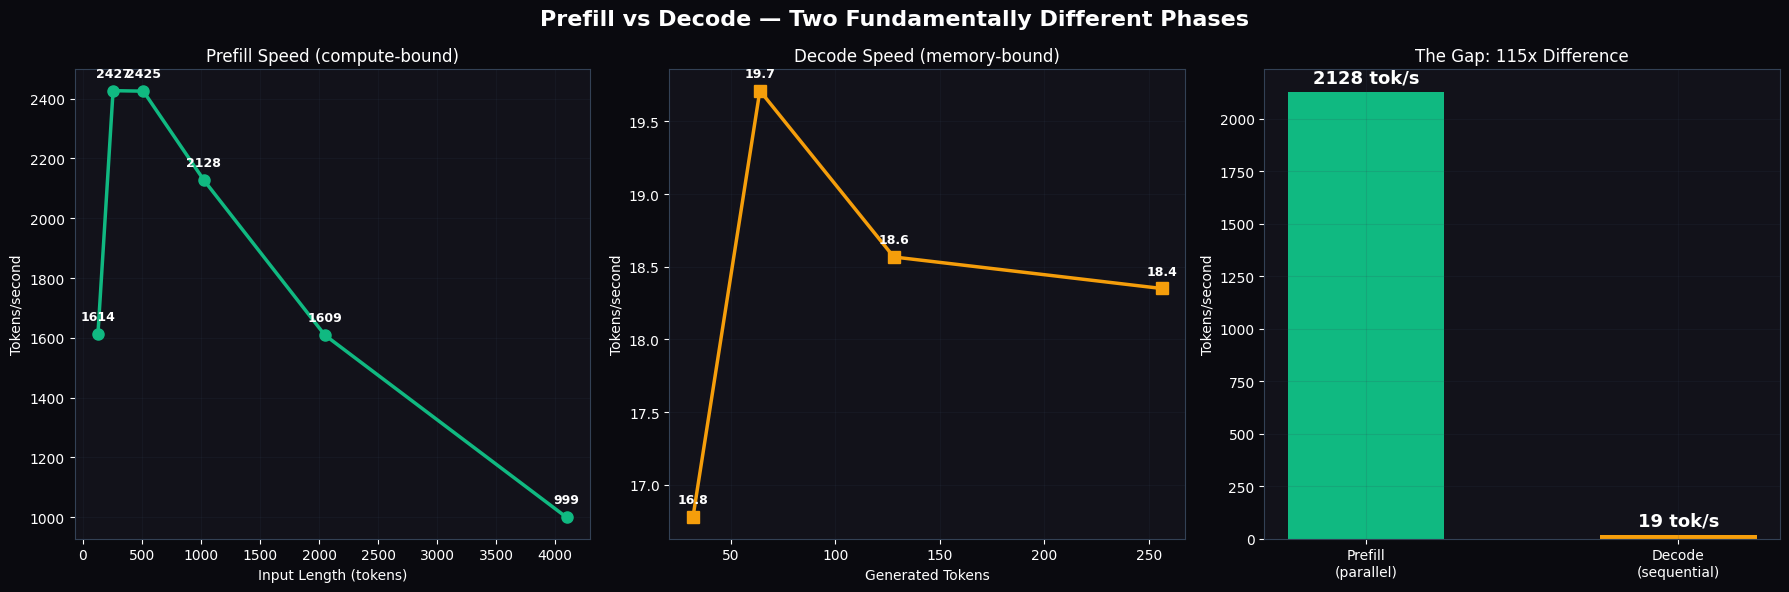

Saved: prefill_vs_decode.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0a0a0f")
for ax in axes:
    ax.set_facecolor("#12121a")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for s in ax.spines.values(): s.set_color("#334155")
    ax.grid(alpha=0.15, color="#334155")

fig.suptitle("Prefill vs Decode — Two Fundamentally Different Phases",
             fontsize=16, fontweight="bold", color="white")

# Chart 1: Prefill throughput vs context length
ax = axes[0]
ctx = [r["ctx"] for r in prefill_results]
tps = [r["tps"] for r in prefill_results]
ax.plot(ctx, tps, "o-", color="#10b981", linewidth=2.5, markersize=8)
for r in prefill_results:
    ax.annotate(f"{r['tps']:.0f}", (r["ctx"], r["tps"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", color="white", fontsize=9, fontweight="bold")
ax.set_xlabel("Input Length (tokens)")
ax.set_ylabel("Tokens/second")
ax.set_title("Prefill Speed (compute-bound)")

# Chart 2: Decode throughput
ax = axes[1]
dtok = [r["tokens"] for r in decode_results]
dtps = [r["tps"] for r in decode_results]
ax.plot(dtok, dtps, "s-", color="#f59e0b", linewidth=2.5, markersize=8)
for r in decode_results:
    ax.annotate(f"{r['tps']:.1f}", (r["tokens"], r["tps"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", color="white", fontsize=9, fontweight="bold")
ax.set_xlabel("Generated Tokens")
ax.set_ylabel("Tokens/second")
ax.set_title("Decode Speed (memory-bound)")

# Chart 3: Side by side comparison
ax = axes[2]
labels = ["Prefill\n(parallel)", "Decode\n(sequential)"]
vals = [prefill_results[3]["tps"], decode_results[2]["tps"]]
colors = ["#10b981", "#f59e0b"]
bars = ax.bar(labels, vals, color=colors, width=0.5)
for i, v in enumerate(vals):
    ax.text(i, v + max(vals)*0.02, f"{v:.0f} tok/s", ha="center",
            fontweight="bold", color="white", fontsize=13)
ax.set_ylabel("Tokens/second")
ax.set_title(f"The Gap: {vals[0]/vals[1]:.0f}x Difference")

plt.tight_layout()
plt.savefig("prefill_vs_decode.png", dpi=150, bbox_inches="tight", facecolor="#0a0a0f")
plt.show()
print("Saved: prefill_vs_decode.png")

## 5. The Theory — Why Disaggregation Works

In [8]:
print("""
================================================================
  PREFILL-DECODE DISAGGREGATION
================================================================

  THE PROBLEM:
  ────────────
  LLM inference has two phases with opposite hardware needs:

  ┌────────────┬──────────────────┬──────────────────┐
  │ Phase      │ Prefill          │ Decode           │
  ├────────────┼──────────────────┼──────────────────┤
  │ What       │ Process prompt   │ Generate tokens  │
  │ Parallelism│ HIGH (all at once)│ NONE (one by one)│
  │ Bottleneck │ GPU compute/FLOPs│ Memory bandwidth │
  │ GPU usage  │ Compute saturated│ Compute idle     │
  │ Ideal GPU  │ High FLOP GPU    │ High bandwidth   │
  │ Example    │ H100 SXM (990TF) │ H100 NVL (high BW)│
  └────────────┴──────────────────┴──────────────────┘

  Running both on same GPU = compromise for both:
  → During prefill: memory bandwidth wasted
  → During decode: compute cores idle
  → Neither phase runs at peak efficiency

  THE SOLUTION — DISAGGREGATION:
  ──────────────────────────────
  Split them onto different hardware:

  User Query
      │
      ▼
  ┌─────────────────┐
  │  Prefill Server  │  ← Compute-optimized GPU
  │  (process prompt) │  ← High FLOP throughput
  └────────┬────────┘
           │ Transfer KV Cache
           ▼
  ┌─────────────────┐
  │  Decode Server   │  ← Memory-optimized GPU
  │  (generate tokens)│  ← High memory bandwidth
  └────────┬────────┘
           │
           ▼
      Response

  KEY SYSTEMS:
  ────────────
  Splitwise (Microsoft, 2023):
  → Split prefill/decode across GPU pairs
  → 1.4x higher throughput at same latency
  → Paper: arxiv.org/abs/2311.18677

  DistServe (PKU, 2024):
  → Disaggregated serving with goodput optimization
  → 2x improvement in SLO attainment
  → Paper: arxiv.org/abs/2401.09670

  TetriInfer (2024):
  → Dynamic scheduling between prefill/decode
  → Adapts allocation based on request mix
  → Paper: arxiv.org/abs/2401.11181

  WHY IT MATTERS:
  → At scale (millions of requests), even 1.4x improvement
    saves massive compute costs
  → Different request types need different ratios:
    Short prompts + long outputs → more decode capacity
    Long prompts + short outputs → more prefill capacity
  → Disaggregation lets you scale each independently

  THE KV CACHE TRANSFER PROBLEM:
  → After prefill, the KV cache must be sent to decode server
  → For a 7B model at 4K context: ~1.5 GB of KV cache
  → Needs high-bandwidth interconnect (NVLink, InfiniBand)
  → This transfer overhead is the main engineering challenge

  WHO USES THIS:
  → Large API providers (likely OpenAI, Anthropic, Google)
  → Any system serving >10K requests/sec
  → Not needed for small deployments
================================================================
""")


  PREFILL-DECODE DISAGGREGATION

  THE PROBLEM:
  ────────────
  LLM inference has two phases with opposite hardware needs:

  ┌────────────┬──────────────────┬──────────────────┐
  │ Phase      │ Prefill          │ Decode           │
  ├────────────┼──────────────────┼──────────────────┤
  │ What       │ Process prompt   │ Generate tokens  │
  │ Parallelism│ HIGH (all at once)│ NONE (one by one)│
  │ Bottleneck │ GPU compute/FLOPs│ Memory bandwidth │
  │ GPU usage  │ Compute saturated│ Compute idle     │
  │ Ideal GPU  │ High FLOP GPU    │ High bandwidth   │
  │ Example    │ H100 SXM (990TF) │ H100 NVL (high BW)│
  └────────────┴──────────────────┴──────────────────┘

  Running both on same GPU = compromise for both:
  → During prefill: memory bandwidth wasted
  → During decode: compute cores idle
  → Neither phase runs at peak efficiency

  THE SOLUTION — DISAGGREGATION:
  ──────────────────────────────
  Split them onto different hardware:

  User Query
      │
      ▼
  ┌─────────

## 6. Summary

In [9]:
print("=" * 70)
print("  PREFILL vs DECODE BENCHMARK SUMMARY")
print("=" * 70)

p_tps = prefill_results[3]["tps"]
d_tps = decode_results[2]["tps"]

print(f"""
  Model: {MODEL_ID}

  ┌──────────────┬──────────────────┬──────────────────┐
  │              │ Prefill          │ Decode           │
  ├──────────────┼──────────────────┼──────────────────┤
  │ Throughput   │ {p_tps:>8.0f} tok/s   │ {d_tps:>8.1f} tok/s   │
  │ Bottleneck   │ Compute (FLOPs)  │ Memory bandwidth │
  │ Parallelism  │ Full parallel    │ Sequential       │
  │ Gap          │ {p_tps/d_tps:.0f}x faster than decode                │
  └──────────────┴──────────────────┴──────────────────┘

  Key Findings:
  1. Prefill is {p_tps/d_tps:.0f}x faster per token than decode
  2. They have OPPOSITE hardware bottlenecks
  3. Running both on same GPU = neither phase at peak efficiency
  4. Disaggregation: prefill on compute GPUs, decode on memory GPUs
  5. Real-world gains: 1.4-2x throughput improvement at scale

  Papers:
  - Splitwise: arxiv.org/abs/2311.18677
  - DistServe: arxiv.org/abs/2401.09670

  Blog: "LLM Inference Has Two Phases — And They Need Different GPUs"
""")
print("=" * 70)

  PREFILL vs DECODE BENCHMARK SUMMARY

  Model: Qwen/Qwen2.5-3B-Instruct

  ┌──────────────┬──────────────────┬──────────────────┐
  │              │ Prefill          │ Decode           │
  ├──────────────┼──────────────────┼──────────────────┤
  │ Throughput   │     2128 tok/s   │     18.6 tok/s   │
  │ Bottleneck   │ Compute (FLOPs)  │ Memory bandwidth │
  │ Parallelism  │ Full parallel    │ Sequential       │
  │ Gap          │ 115x faster than decode                │
  └──────────────┴──────────────────┴──────────────────┘

  Key Findings:
  1. Prefill is 115x faster per token than decode
  2. They have OPPOSITE hardware bottlenecks
  3. Running both on same GPU = neither phase at peak efficiency
  4. Disaggregation: prefill on compute GPUs, decode on memory GPUs
  5. Real-world gains: 1.4-2x throughput improvement at scale

  Papers:
  - Splitwise: arxiv.org/abs/2311.18677
  - DistServe: arxiv.org/abs/2401.09670

  Blog: "LLM Inference Has Two Phases — And They Need Different GPUs

## LinkedIn Post — Post 9: Prefill vs Decode

---

**Most people think LLM inference is one thing. It's actually two — and they're complete opposites.**

I ran benchmarks on a T4 GPU with Qwen2.5-3B to prove it.

---

**The numbers don't lie:**

Prefill phase (processing your prompt):
→ 2,128 tokens/sec at 1,024 tokens
→ GPU compute is maxed out
→ All tokens processed **in parallel** — pure matrix multiply

Decode phase (generating the response):
→ 18.6 tokens/sec
→ Memory bandwidth is the bottleneck
→ One token at a time — **115x slower per token**

Same GPU. Same model. 115x throughput difference.

---

**Why does this gap exist?**

Prefill is **compute-bound**: you feed the full prompt as one big matrix multiply. The GPU loves this — FLOPs saturated.

Decode is **memory-bound**: every new token requires reading the entire KV cache from GPU memory. The GPU's compute cores sit idle, waiting on memory reads.

Running both on the same GPU means neither phase runs at peak efficiency. It's like using a Ferrari for both highway racing and parking — you're always compromising.

---

**The solution: Disaggregation**

Split the two phases onto purpose-built hardware:

- **Prefill Server** → High-FLOP GPU (H100 SXM) — 990 TFLOPS
- **Decode Server** → High-bandwidth GPU (H100 NVL) — optimized memory BW
- Transfer the KV cache between them (~1.5 GB for a 7B model at 4K context)

Real-world results from published research:
- **Splitwise** (Microsoft, 2023): 1.4x throughput gain
- **DistServe** (PKU, 2024): 2x improvement in SLO attainment

---

**Why it matters at scale**

If you're serving millions of requests/day, 1.4x throughput = significant cost reduction.

Different workloads also have different ratios:
- Long prompt + short output → need more prefill capacity
- Short prompt + long output → need more decode capacity

Disaggregation lets you scale each independently.

The engineering challenge? That KV cache transfer. At 4K context on a 7B model, you're moving ~1.5 GB per request across GPUs. That needs NVLink or InfiniBand to not become the new bottleneck.

---

**Full benchmark notebook + code:**
github.com/shubh2579/Prefill-Decode-Segregation-Experiment

Papers:
- Splitwise: arxiv.org/abs/2311.18677
- DistServe: arxiv.org/abs/2401.09670
- TetriInfer: arxiv.org/abs/2401.11181

---

*Measured on Tesla T4 (15.6 GB VRAM), Qwen/Qwen2.5-3B-Instruct, float16*

#LLM #MachineLearning #MLInfrastructure #AIEngineering #DeepLearning #LLMInference #GPUOptimization